In [1]:
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
from shapely.validation import explain_validity


In [2]:
# 第一步：解析 GML/XML 文件
file_path = r"C:\Users\86125\Downloads\qld-govt-dehp-qld-heritage-register-2016-na.xml"
tree = ET.parse(file_path)
root = tree.getroot()
# 设置 GML 命名空间
ns = {
    'gml': 'http://www.opengis.net/gml/3.2',
    'wfs': 'http://www.opengis.net/wfs/2.0',
    'aurin': 'http://datasource-QLD_Govt_DEHP-UoM_AURIN_DB'
}


In [3]:
# 第二步：提取 footprint 和属性信息
features = []
for member in root.findall('wfs:member', ns):
    placename = member.find('.//aurin:placename', ns).text
    area_sqm = float(member.find('.//aurin:area_sqm', ns).text)
    posList = member.find('.//gml:posList', ns)
    if posList is None:
        continue
    
    coords_text = posList.text.strip().split()
    coords = [(float(coords_text[i+1]), float(coords_text[i])) for i in range(0, len(coords_text), 2)]
    
    try:
        polygon = Polygon(coords)
        features.append({
            'placename': placename,
            'area_sqm': area_sqm,
            'geometry': polygon
        })
    except Exception as e:
        print(f"跳过非法几何：{placename}, 错误: {e}")


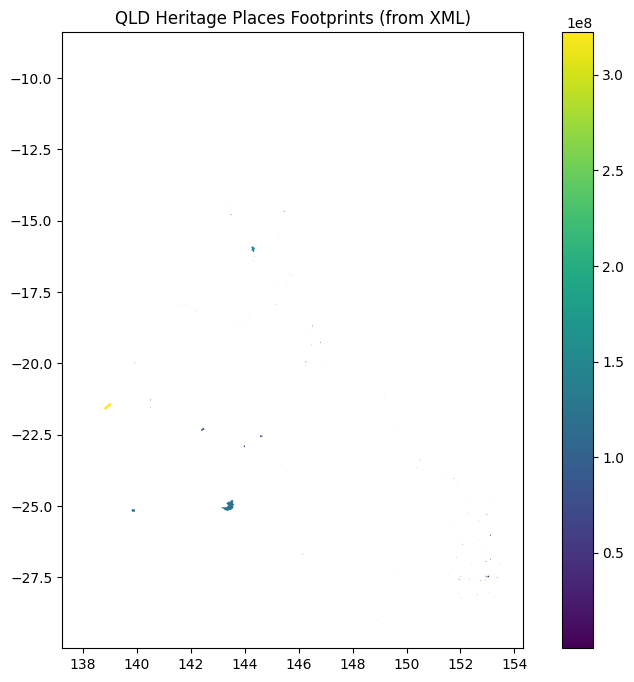

In [4]:
# 第三步：构建 GeoDataFrame 并可视化
gdf = gpd.GeoDataFrame(features, crs="EPSG:4283")

# 可视化结果
gdf.plot(column="area_sqm", legend=True, figsize=(10, 8))
plt.title("QLD Heritage Places Footprints (from XML)")
plt.show()


In [5]:
# 第四步：验证逻辑（示例）
gdf["is_valid"] = gdf["geometry"].apply(lambda g: g.is_valid and g.is_simple)
gdf["area_check"] = gdf["area_sqm"] > 100  # 超过 100 平方米为有效面积
print(gdf[["placename", "is_valid", "area_check"]].head())


                       placename  is_valid  area_check
0                        Monkton      True        True
1  Stewart's Creek Gaol (former)      True        True
2     Old Westmoreland Homestead      True        True
3           St Mary's Presbytery      True        True
4                   Mango Avenue      True        True


In [6]:

# 计算多边形内角函数（返回所有角度）
def calculate_internal_angles(polygon: Polygon):
    coords = list(polygon.exterior.coords)
    angles = []
    for i in range(len(coords) - 2):  # 不包含重复首尾点
        p0 = np.array(coords[i])
        p1 = np.array(coords[i+1])
        p2 = np.array(coords[i+2])
        
        v1 = p0 - p1
        v2 = p2 - p1
        
        cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
        angles.append(np.degrees(angle))
    return angles

# 添加规则列
def validate_geometry(geom):
    if not geom.is_valid:
        return {
            "is_valid": False,
            "reason": explain_validity(geom),
            "min_angle": None,
            "min_angle_pass": False,
            "num_edges": None,
            "num_edges_pass": False
        }

    angles = calculate_internal_angles(geom)
    min_angle = min(angles) if angles else None
    min_angle_pass = min_angle is None or min_angle >= 30

    coords = list(geom.exterior.coords)
    num_edges = len(coords) - 1  # 因为首尾重复
    num_edges_pass = num_edges >= 4

    return {
        "is_valid": True,
        "reason": "Valid",
        "min_angle": min_angle,
        "min_angle_pass": min_angle_pass,
        "num_edges": num_edges,
        "num_edges_pass": num_edges_pass
    }

# 应用规则
rule_results = gdf["geometry"].apply(validate_geometry)
rule_df = pd.DataFrame(rule_results.tolist())

# 合并到原始 GeoDataFrame
gdf = pd.concat([gdf, rule_df], axis=1)

# 显示部分不合规数据
invalid = gdf[(~gdf["min_angle_pass"]) | (~gdf["num_edges_pass"])]
print(invalid[["placename", "min_angle", "num_edges", "min_angle_pass", "num_edges_pass"]])


                                              placename  min_angle  num_edges  \
10                    Normanton to Croydon Railway Line        NaN        NaN   
37    La Societe Fransaise des Metaux Rares treatmen...  27.474429       14.0   
46                    Old Cleveland Road Tramway Tracks  19.980568       85.0   
81                             Central Sugar Mill Ruins  42.396703        3.0   
140                               Mount Coot-tha Forest  15.437147      204.0   
141                               Toowong Memorial Park  22.224935       36.0   
145                                       Victoria Park   3.676025       95.0   
153                                       Railway Hotel  22.700268        8.0   
180   Glass House Mountains National Park and Beerbu...  19.699769      273.0   
234              No. 1 Scottish Gympie Mine and Battery  17.732696       39.0   
235                           Toowong Municipal Library  19.605032       15.0   
246             Habana Traml

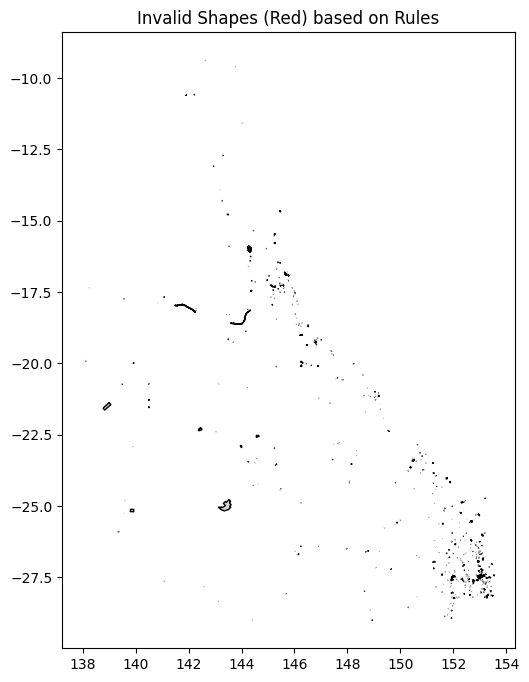

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, color="lightgrey", edgecolor="black")
invalid.plot(ax=ax, color="red", edgecolor="black")
plt.title("Invalid Shapes (Red) based on Rules")
plt.show()


In [8]:
# 确保重新生成 rule_df 并去除重复列名
rule_results = gdf["geometry"].apply(validate_geometry)
rule_df = pd.DataFrame(rule_results.tolist())

# 防止重复列名：手动设置列名清晰
rule_df.columns = ['is_geom_valid', 'reason', 'min_angle', 'min_angle_pass', 'num_edges', 'num_edges_pass']

# 合并进 GeoDataFrame
gdf = gdf.drop(columns=[c for c in ['is_valid', 'min_angle_pass', 'num_edges_pass'] if c in gdf.columns], errors='ignore')
gdf = pd.concat([gdf, rule_df], axis=1)

In [9]:
# 筛选非法图形
invalid_shapes = gdf[
    (~gdf["is_geom_valid"]) |
    (~gdf["min_angle_pass"]) |
    (~gdf["num_edges_pass"])
].copy()


In [10]:
# 问题描述函数
def issue_description(row):
    issues = []

    # 抽取值，确保是 float 或 bool，而不是 Series
    min_angle = row["min_angle"]
    min_angle_pass = row["min_angle_pass"]
    is_geom_valid = row["is_geom_valid"]
    num_edges_pass = row["num_edges_pass"]
    reason = row["reason"]
    num_edges = row["num_edges"]

    # 错误判断
    if isinstance(is_geom_valid, (pd.Series, list)): is_geom_valid = is_geom_valid.iloc[0]
    if isinstance(min_angle_pass, (pd.Series, list)): min_angle_pass = min_angle_pass.iloc[0]
    if isinstance(num_edges_pass, (pd.Series, list)): num_edges_pass = num_edges_pass.iloc[0]
    if isinstance(min_angle, (pd.Series, list)): min_angle = min_angle.iloc[0]
    if isinstance(num_edges, (pd.Series, list)): num_edges = num_edges.iloc[0]

    if not is_geom_valid:
        issues.append(f"Invalid Geometry: {reason}")
    if not min_angle_pass:
        if pd.notnull(min_angle):
            issues.append(f"Minimum angle too small: {min_angle:.2f}°")
        else:
            issues.append("Minimum angle missing or invalid")
    if not num_edges_pass:
        issues.append(f"Too few edges: {num_edges}")
    
    return "; ".join(issues)


In [11]:
invalid_shapes["problem_description"] = invalid_shapes.apply(issue_description, axis=1)
# 显示前几条
print(invalid_shapes[["placename", "problem_description"]].head(10))


                                             placename  \
10                   Normanton to Croydon Railway Line   
37   La Societe Fransaise des Metaux Rares treatmen...   
46                   Old Cleveland Road Tramway Tracks   
81                            Central Sugar Mill Ruins   
140                              Mount Coot-tha Forest   
141                              Toowong Memorial Park   
145                                      Victoria Park   
153                                      Railway Hotel   
180  Glass House Mountains National Park and Beerbu...   
234             No. 1 Scottish Gympie Mine and Battery   

                                   problem_description  
10   Invalid Geometry: reason    Ring Self-intersec...  
37                     Minimum angle too small: 27.47°  
46                     Minimum angle too small: 19.98°  
81                                  Too few edges: 3.0  
140                    Minimum angle too small: 15.44°  
141                

In [12]:
# 导出为 CSV 报告
invalid_shapes[["placename", "problem_description"]].to_csv("invalid_shapes_report.csv", index=False)
